<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/Homework7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
CIFAR-10 Classification with CNN and ResNet (Optimized)
=======================================================
This notebook implements:
- Problem 1.a: Basic CNN
- Problem 1.b: Extended CNN (additional conv layer)
- Problem 2.a: ResNet-10
- Problem 2.b: ResNet-10 with regularization (Weight Decay, Dropout, Batch Norm)

Optimizations applied:
- Automatic Mixed Precision (AMP) for faster training on GPU.
- Increased batch size (256) and num_workers (4).
- Pinned memory for faster data transfer.
- Epochs set to 100.
"""

# ============================================================================
# CELL 1: Imports and Setup
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"{'='*40}")
print(f"Device configuration: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Usage: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
    # Optimize CUDA for fixed-size input images (faster training)
    torch.backends.cudnn.benchmark = True
else:
    print("WARNING: You are running on CPU. Training will be very slow.")
print(f"{'='*40}")

# Set random seed
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============================================================================
# CELL 2: Load CIFAR-10 Dataset (OPTIMIZED)
# ============================================================================
# Data augmentation and normalization
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# OPTIMIZATION: Batch size 256, 4 workers, pin_memory=True
BATCH_SIZE = 256

print("Downloading/Loading CIFAR-10 data...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=4, pin_memory=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")

# ============================================================================
# CELL 3: Utility Functions (OPTIMIZED WITH AMP)
# ============================================================================
def count_parameters(model):
    """Count the number of trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model):
    """Get model size in MB"""
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_mb = (param_size + buffer_size) / 1024**2
    return size_mb

def train_model(model, trainloader, testloader, epochs=100, lr=0.001,
                weight_decay=0, model_name="Model"):
    """
    Train a model ensuring GPU usage and Mixed Precision (AMP)
    """
    # MOVE MODEL TO GPU
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Use AMP (Automatic Mixed Precision) only if using CUDA
    use_amp = True if device.type == 'cuda' else False
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    train_losses = []
    test_accuracies = []

    print(f"\n{'='*60}")
    print(f"Training {model_name} on {device}")
    print(f"Parameters: {count_parameters(model):,}")
    print(f"Model Size: {get_model_size_mb(model):.2f} MB")
    print(f"{'='*60}")

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for i, (inputs, labels) in enumerate(trainloader):
            # MOVE DATA TO GPU (non_blocking allows async transfer)
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            # Forward pass with Mixed Precision
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            # Backward pass with scaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        epoch_loss = running_loss / len(trainloader)
        train_losses.append(epoch_loss)

        # Evaluate every 10 epochs (or first epoch)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, labels in testloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            test_accuracies.append((epoch + 1, accuracy))
            print(f"Epoch [{epoch+1:3d}/{epochs}] - Loss: {epoch_loss:.4f} - Test Acc: {accuracy:.2f}%")

    total_time = time.time() - start_time

    # Final evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    final_accuracy = 100 * correct / total

    results = {
        'model_name': model_name,
        'train_losses': train_losses,
        'test_accuracies': test_accuracies,
        'final_accuracy': final_accuracy,
        'final_loss': train_losses[-1],
        'training_time': total_time,
        'num_parameters': count_parameters(model),
        'model_size_mb': get_model_size_mb(model)
    }

    print(f"\n{'-'*40}")
    print(f"Final Results for {model_name}:")
    print(f"Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Final Test Accuracy: {final_accuracy:.2f}%")
    print(f"{'-'*40}\n")

    return results

# ============================================================================
# CELL 4: Problem 1.a - Basic CNN
# ============================================================================
class BasicCNN(nn.Module):
    """
    Basic CNN for CIFAR-10 classification
    """
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # 32 -> 16 -> 8, so 8x8x64 = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Problem 1.a: Basic CNN Architecture")
model_1a = BasicCNN()

# ============================================================================
# CELL 5: Train Problem 1.a
# ============================================================================
results_1a = train_model(model_1a, trainloader, testloader, epochs=100,
                         model_name="Basic CNN (Problem 1.a)")

Device configuration: cuda
GPU Name: Tesla T4
Memory Usage: 0.00 GB
Downloading/Loading CIFAR-10 data...


100%|██████████| 170M/170M [00:11<00:00, 15.0MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training samples: 50000
Test samples: 10000
Problem 1.a: Basic CNN Architecture

Training Basic CNN (Problem 1.a) on cuda
Parameters: 2,122,186
Model Size: 8.10 MB


/tmp/ipython-input-2575830900.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-2575830900.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [  1/100] - Loss: 1.5986 - Test Acc: 54.97%
Epoch [ 10/100] - Loss: 0.7510 - Test Acc: 74.87%
Epoch [ 20/100] - Loss: 0.5828 - Test Acc: 78.64%
Epoch [ 30/100] - Loss: 0.4892 - Test Acc: 79.37%
Epoch [ 40/100] - Loss: 0.3866 - Test Acc: 81.53%
Epoch [ 50/100] - Loss: 0.3728 - Test Acc: 81.98%
Epoch [ 60/100] - Loss: 0.3591 - Test Acc: 81.76%
Epoch [ 70/100] - Loss: 0.3455 - Test Acc: 81.96%
Epoch [ 80/100] - Loss: 0.3452 - Test Acc: 81.94%
Epoch [ 90/100] - Loss: 0.3417 - Test Acc: 82.03%
Epoch [100/100] - Loss: 0.3424 - Test Acc: 82.01%

----------------------------------------
Final Results for Basic CNN (Problem 1.a):
Training Time: 1713.21 seconds (28.55 minutes)
Final Training Loss: 0.3424
Final Test Accuracy: 82.01%
----------------------------------------



In [2]:
# ============================================================================
# CELL 6: Problem 1.b - Extended CNN
# ============================================================================
class ExtendedCNN(nn.Module):
    """
    Extended CNN with additional convolutional layer
    """
    def __init__(self):
        super(ExtendedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # New layer
        self.pool = nn.MaxPool2d(2, 2)
        # 32 -> 16 -> 8 -> 4, so 4x4x128 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Problem 1.b: Extended CNN Architecture")
model_1b = ExtendedCNN()

# ============================================================================
# CELL 7: Train Problem 1.b
# ============================================================================
results_1b = train_model(model_1b, trainloader, testloader, epochs=100,
                         model_name="Extended CNN (Problem 1.b)")

Problem 1.b: Extended CNN Architecture

Training Extended CNN (Problem 1.b) on cuda
Parameters: 1,147,466
Model Size: 4.38 MB


/tmp/ipython-input-2575830900.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-2575830900.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [  1/100] - Loss: 1.6222 - Test Acc: 50.63%
Epoch [ 10/100] - Loss: 0.6517 - Test Acc: 76.63%
Epoch [ 20/100] - Loss: 0.4736 - Test Acc: 79.98%
Epoch [ 30/100] - Loss: 0.3734 - Test Acc: 82.00%
Epoch [ 40/100] - Loss: 0.2577 - Test Acc: 84.04%
Epoch [ 50/100] - Loss: 0.2339 - Test Acc: 84.04%
Epoch [ 60/100] - Loss: 0.2189 - Test Acc: 84.04%
Epoch [ 70/100] - Loss: 0.2060 - Test Acc: 84.20%
Epoch [ 80/100] - Loss: 0.2021 - Test Acc: 84.22%
Epoch [ 90/100] - Loss: 0.2027 - Test Acc: 84.21%
Epoch [100/100] - Loss: 0.2010 - Test Acc: 84.18%

----------------------------------------
Final Results for Extended CNN (Problem 1.b):
Training Time: 1721.17 seconds (28.69 minutes)
Final Training Loss: 0.2010
Final Test Accuracy: 84.18%
----------------------------------------



In [3]:
# ============================================================================
# CELL 8: Problem 2.a - ResNet-10
# ============================================================================
class ResidualBlock(nn.Module):
    """Basic Residual Block with skip connection"""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet10(nn.Module):
    """ResNet-10 for CIFAR-10"""
    def __init__(self, num_classes=10):
        super(ResNet10, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 3, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

print("Problem 2.a: ResNet-10 Architecture")
model_2a = ResNet10()

# ============================================================================
# CELL 9: Train Problem 2.a
# ============================================================================
results_2a = train_model(model_2a, trainloader, testloader, epochs=50,
                         model_name="ResNet-10 (Problem 2.a)")

Problem 2.a: ResNet-10 Architecture

Training ResNet-10 (Problem 2.a) on cuda
Parameters: 17,075,274
Model Size: 65.19 MB


/tmp/ipython-input-2575830900.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-2575830900.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [  1/50] - Loss: 1.5979 - Test Acc: 51.01%
Epoch [ 10/50] - Loss: 0.3459 - Test Acc: 85.49%
Epoch [ 20/50] - Loss: 0.1659 - Test Acc: 89.09%
Epoch [ 30/50] - Loss: 0.0910 - Test Acc: 89.72%
Epoch [ 40/50] - Loss: 0.0119 - Test Acc: 93.36%
Epoch [ 50/50] - Loss: 0.0063 - Test Acc: 93.25%

----------------------------------------
Final Results for ResNet-10 (Problem 2.a):
Training Time: 1127.52 seconds (18.79 minutes)
Final Training Loss: 0.0063
Final Test Accuracy: 93.25%
----------------------------------------



In [4]:
# ============================================================================
# CELL 10: Problem 2.b - ResNet-10 Variants
# ============================================================================

# Variant 1: Regular ResNet10 (will use Weight Decay in optimizer)
class ResNet10_WeightDecay(ResNet10):
    pass

# Variant 2: Dropout
class ResidualBlockDropout(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout_p=0.3):
        super(ResidualBlockDropout, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(p=dropout_p)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet10_Dropout(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.3):
        super(ResNet10_Dropout, self).__init__()
        self.in_channels = 64
        self.dropout_p = dropout_p
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 3, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlockDropout(self.in_channels, out_channels,
                                               stride, self.dropout_p))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# Variant 3: Enhanced Batch Norm
class ResidualBlockEnhancedBN(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlockEnhancedBN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels, momentum=0.1, affine=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels, momentum=0.1, affine=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels, momentum=0.1, affine=True)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet10_BatchNorm(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet10_BatchNorm, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.1, affine=True)
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 3, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlockEnhancedBN(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# ============================================================================
# CELL 11: Train Problem 2.b - Weight Decay
# ============================================================================
print("\n" + "="*60)
print("Problem 2.b: ResNet-10 with Regularization")
print("="*60)

model_2b_wd = ResNet10()
results_2b_wd = train_model(model_2b_wd, trainloader, testloader, epochs=50,
                            weight_decay=0.001,
                            model_name="ResNet-10 + Weight Decay (λ=0.001)")

# ============================================================================
# CELL 12: Train Problem 2.b - Dropout
# ============================================================================
model_2b_dropout = ResNet10_Dropout(dropout_p=0.3)
results_2b_dropout = train_model(model_2b_dropout, trainloader, testloader, epochs=50,
                                 model_name="ResNet-10 + Dropout (p=0.3)")

# ============================================================================
# CELL 13: Train Problem 2.b - Batch Normalization
# ============================================================================
model_2b_bn = ResNet10_BatchNorm()
results_2b_bn = train_model(model_2b_bn, trainloader, testloader, epochs=50,
                            model_name="ResNet-10 + Batch Norm (Enhanced)")



Problem 2.b: ResNet-10 with Regularization

Training ResNet-10 + Weight Decay (λ=0.001) on cuda
Parameters: 17,075,274
Model Size: 65.19 MB


/tmp/ipython-input-2575830900.py:118: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-2575830900.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch [  1/50] - Loss: 1.6229 - Test Acc: 43.60%
Epoch [ 10/50] - Loss: 0.4827 - Test Acc: 77.73%
Epoch [ 20/50] - Loss: 0.3328 - Test Acc: 86.16%
Epoch [ 30/50] - Loss: 0.2806 - Test Acc: 83.96%
Epoch [ 40/50] - Loss: 0.0905 - Test Acc: 92.15%
Epoch [ 50/50] - Loss: 0.0555 - Test Acc: 92.10%

----------------------------------------
Final Results for ResNet-10 + Weight Decay (λ=0.001):
Training Time: 1078.95 seconds (17.98 minutes)
Final Training Loss: 0.0555
Final Test Accuracy: 92.10%
----------------------------------------


Training ResNet-10 + Dropout (p=0.3) on cuda
Parameters: 17,075,274
Model Size: 65.19 MB
Epoch [  1/50] - Loss: 1.6364 - Test Acc: 53.34%
Epoch [ 10/50] - Loss: 0.4333 - Test Acc: 85.70%
Epoch [ 20/50] - Loss: 0.2593 - Test Acc: 88.95%
Epoch [ 30/50] - Loss: 0.1640 - Test Acc: 89.57%
Epoch [ 40/50] - Loss: 0.0651 - Test Acc: 92.83%
Epoch [ 50/50] - Loss: 0.0506 - Test Acc: 92.99%

----------------------------------------
Final Results for ResNet-10 + Dropout (


FINAL RESULTS SUMMARY

Model                                               Params  Size (MB)   Time (min)   Final Loss   Accuracy
---------------------------------------------------------------------------------------------------------
Basic CNN (Problem 1.a)                          2,122,186       8.10        28.55       0.3424     82.01%
Extended CNN (Problem 1.b)                       1,147,466       4.38        28.69       0.2010     84.18%
ResNet-10 (Problem 2.a)                         17,075,274      65.19        18.79       0.0063     93.25%
ResNet-10 + Weight Decay (λ=0.001)              17,075,274      65.19        17.98       0.0555     92.10%
ResNet-10 + Dropout (p=0.3)                     17,075,274      65.19        18.69       0.0506     92.99%
ResNet-10 + Batch Norm (Enhanced)               17,075,274      65.19        18.31       0.0059     93.04%


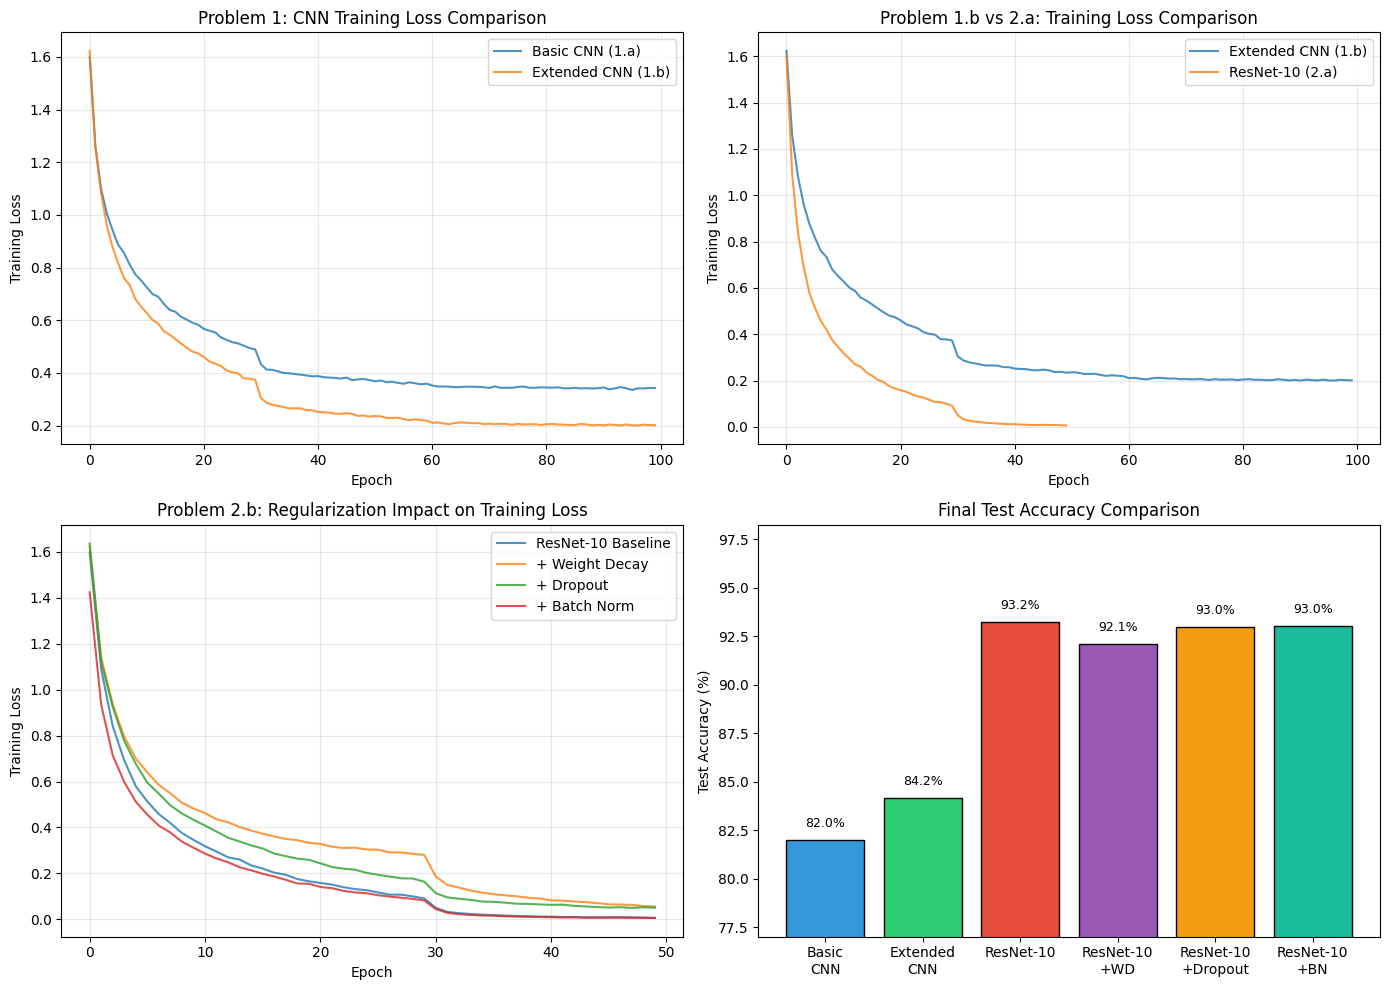


OVERFITTING ANALYSIS (Problem 1.b)

Extended CNN (Problem 1.b):
  Training Accuracy: 92.83%
  Test Accuracy: 84.18%
  Gap (Train - Test): 8.65%
  Analysis: MODERATE OVERFITTING detected (gap > 5%)


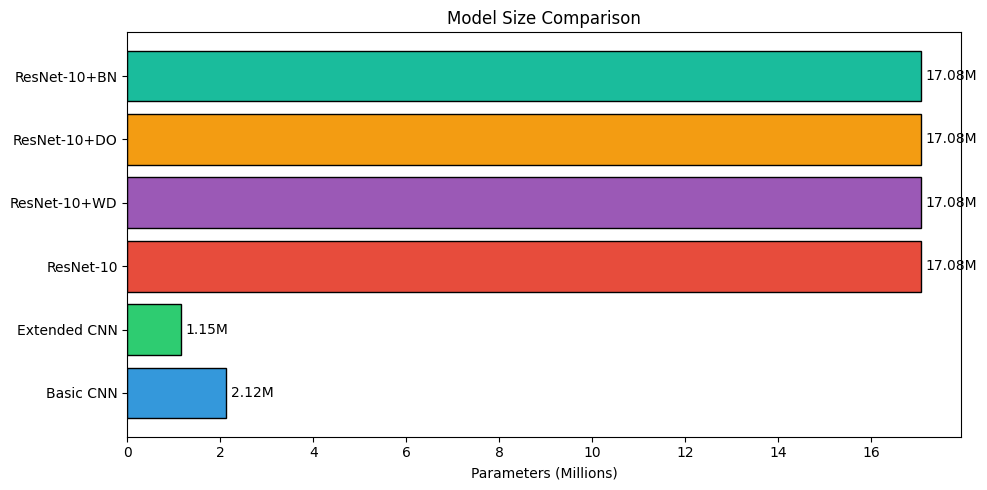


ANALYSIS FOR REPORT

PROBLEM 1.a vs 1.b COMPARISON:
------------------------------
The Extended CNN (1.b) adds a third convolutional layer (64->128 channels) with
additional pooling. This increases the model's capacity to learn hierarchical
features but also increases the parameter count.

PROBLEM 2.a (ResNet-10) ANALYSIS:
---------------------------------
ResNet-10 uses skip connections which allow:
1. Better gradient flow during backpropagation
2. Ability to train deeper networks
3. Learning residual functions rather than direct mappings

PROBLEM 2.b REGULARIZATION ANALYSIS:
------------------------------------
1. Weight Decay (L2 Regularization): Penalizes large weights, reducing overfitting.
2. Dropout: Randomly drops neurons, acting as ensemble learning.
3. Batch Normalization: Normalizes activations, allowing faster training and
   providing a slight regularization effect.


END OF NOTEBOOK


In [5]:
# ============================================================================
# CELL 14: Results Summary and Comparison
# ============================================================================
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

all_results = [
    results_1a,
    results_1b,
    results_2a,
    results_2b_wd,
    results_2b_dropout,
    results_2b_bn
]

# Create summary table
print(f"\n{'Model':<45} {'Params':>12} {'Size (MB)':>10} {'Time (min)':>12} {'Final Loss':>12} {'Accuracy':>10}")
print("-" * 105)

for r in all_results:
    print(f"{r['model_name']:<45} {r['num_parameters']:>12,} {r['model_size_mb']:>10.2f} "
          f"{r['training_time']/60:>12.2f} {r['final_loss']:>12.4f} {r['final_accuracy']:>9.2f}%")

# ============================================================================
# CELL 15: Visualization
# ============================================================================
# Plot training losses
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Problem 1 comparison
ax1 = axes[0, 0]
ax1.plot(results_1a['train_losses'], label='Basic CNN (1.a)', alpha=0.8)
ax1.plot(results_1b['train_losses'], label='Extended CNN (1.b)', alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Problem 1: CNN Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Problem 2a vs 1b
ax2 = axes[0, 1]
ax2.plot(results_1b['train_losses'], label='Extended CNN (1.b)', alpha=0.8)
ax2.plot(results_2a['train_losses'], label='ResNet-10 (2.a)', alpha=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Training Loss')
ax2.set_title('Problem 1.b vs 2.a: Training Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Problem 2b regularization comparison
ax3 = axes[1, 0]
ax3.plot(results_2a['train_losses'], label='ResNet-10 Baseline', alpha=0.8)
ax3.plot(results_2b_wd['train_losses'], label='+ Weight Decay', alpha=0.8)
ax3.plot(results_2b_dropout['train_losses'], label='+ Dropout', alpha=0.8)
ax3.plot(results_2b_bn['train_losses'], label='+ Batch Norm', alpha=0.8)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Training Loss')
ax3.set_title('Problem 2.b: Regularization Impact on Training Loss')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Accuracy comparison bar chart
ax4 = axes[1, 1]
model_names = ['Basic\nCNN', 'Extended\nCNN', 'ResNet-10', 'ResNet-10\n+WD',
               'ResNet-10\n+Dropout', 'ResNet-10\n+BN']
accuracies = [r['final_accuracy'] for r in all_results]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
bars = ax4.bar(model_names, accuracies, color=colors, edgecolor='black')
ax4.set_ylabel('Test Accuracy (%)')
ax4.set_title('Final Test Accuracy Comparison')
ax4.set_ylim([min(accuracies) - 5, max(accuracies) + 5])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# CELL 16: Overfitting Analysis
# ============================================================================
print("\n" + "="*80)
print("OVERFITTING ANALYSIS (Problem 1.b)")
print("="*80)

# Compute training accuracy for Extended CNN to check overfitting
model_1b_check = ExtendedCNN().to(device)
model_1b_check.load_state_dict(model_1b.state_dict())

model_1b_check.eval()
train_correct = 0
train_total = 0
with torch.no_grad():
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1b_check(inputs)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

train_acc_1b = 100 * train_correct / train_total
test_acc_1b = results_1b['final_accuracy']
gap_1b = train_acc_1b - test_acc_1b

print(f"\nExtended CNN (Problem 1.b):")
print(f"  Training Accuracy: {train_acc_1b:.2f}%")
print(f"  Test Accuracy: {test_acc_1b:.2f}%")
print(f"  Gap (Train - Test): {gap_1b:.2f}%")

if gap_1b > 10:
    print(f"  Analysis: SIGNIFICANT OVERFITTING detected (gap > 10%)")
elif gap_1b > 5:
    print(f"  Analysis: MODERATE OVERFITTING detected (gap > 5%)")
else:
    print(f"  Analysis: MINIMAL OVERFITTING (gap <= 5%)")

# ============================================================================
# CELL 17: Model Size Comparison Chart
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

model_names_short = ['Basic CNN', 'Extended CNN', 'ResNet-10',
                     'ResNet-10+WD', 'ResNet-10+DO', 'ResNet-10+BN']
params = [r['num_parameters']/1e6 for r in all_results]  # In millions

bars = ax.barh(model_names_short, params, color=colors, edgecolor='black')
ax.set_xlabel('Parameters (Millions)')
ax.set_title('Model Size Comparison')

for bar, p in zip(bars, params):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{p:.2f}M', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# CELL 19: Analysis and Discussion
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS FOR REPORT")
print("="*80)

print("""
PROBLEM 1.a vs 1.b COMPARISON:
------------------------------
The Extended CNN (1.b) adds a third convolutional layer (64->128 channels) with
additional pooling. This increases the model's capacity to learn hierarchical
features but also increases the parameter count.

PROBLEM 2.a (ResNet-10) ANALYSIS:
---------------------------------
ResNet-10 uses skip connections which allow:
1. Better gradient flow during backpropagation
2. Ability to train deeper networks
3. Learning residual functions rather than direct mappings

PROBLEM 2.b REGULARIZATION ANALYSIS:
------------------------------------
1. Weight Decay (L2 Regularization): Penalizes large weights, reducing overfitting.
2. Dropout: Randomly drops neurons, acting as ensemble learning.
3. Batch Normalization: Normalizes activations, allowing faster training and
   providing a slight regularization effect.
""")

print("\n" + "="*80)
print("END OF NOTEBOOK")
print("="*80)